In [1]:
# =============================================================================
# Quina taula de multiplicar es mes dificil? (A998, Espanya, curs 2025-26)
# =============================================================================
# Pregunta del Learning Team: quina taula costa mes -- desglossat en error rate
# i response time -- i com varia amb l'edat. Enfocament inicial: taules 6/7/8/9.
#
# "Taula del X" es ambigua (8x7 es taula del 8 o del 7?), aixi que aquest
# notebook calcula TRES definicions en paral·lel des d'una unica query
# agregada (a998_table_difficulty_by_age.sql):
#   'either'  -- X es qualsevol dels dos factors (8x7 i 7x8 compten per taula 8)
#   'first'   -- X es estrictament el primer factor  (8x7 si, 7x8 no)
#   'second'  -- X es estrictament el segon factor    (7x8 si, 8x7 no)
# L'asimetria commutativa en si (8x7 vs 7x8 es responen diferent?) queda per
# mes endavant -- aqui nomes es defineix "taula", no es mesura l'asimetria.
#
# Decisions heretades de Learning_Team_Plots/Decisions.txt:
#   #1 A998 nomes  ·  #2 edats 8-15 (classroom_course_age)  ·  #5 nomes
#   multiplicacions per classificar taula  ·  #7 es descarta el primer
#   statement de cada pack-sitting (biaix de compte enrere / orientacio)
#
# Error rate = (Incorrect + Help) / n intents.
# Response time = mitjana nomes sobre respostes CORRECTES (convencio de
# rt_A998_answers.sql: una resposta incorrecta rapida no es evidencia de
# fluidesa).
#
# RAPID-GUESSING FILTER (Maria, 2026-08-13): the underlying queries
# (a998_table_difficulty_by_age.sql, a998_fact_heatmap_by_age.sql) now drop
# Incorrect/Help answers under 1.2s before aggregating, to keep fast
# disengaged guesses out of the "hardest table/fact" ranking. This could NOT
# be done here in the notebook: agg_all/fact_df only ever arrive already
# aggregated (error_rate, mean_rt/median_rt, n per cell) -- no per-statement
# is_correct/rt_seconds ever reaches this Python code, so the filter has to
# live in the SQL WHERE clause, before the GROUP BY. Editing the .sql file is
# enough: cached_query() re-fetches automatically because the file content
# (and therefore its cache hash) changed.
# CAVEAT: this filter only removes rows from the WRONG side, so it can only
# ever LOWER a cell's computed error_rate, never raise it -- see the .sql
# files for the full writeup and for a symmetric alternative.
#
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


HERE = Path.cwd()          # descriptive/ or mechanistic/ (run the notebook from its own folder)
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent      # repo root -- holds databricks_connector.py and cached_query.py
sys.path.insert(0, str(ROOT))
from cached_query import cached_query
(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)

SQL_PATH = HERE / "queries" / "a998_table_difficulty_by_age.sql"
CACHE_DIR = HERE / "cache"

agg_all = cached_query(SQL_PATH, CACHE_DIR)

DEFINITIONS = {
    "either": "Taula del X = X es qualsevol dels dos factors (8x7 i 7x8 compten per taula del 8)",
    "first":  "Taula del X = X es estrictament el primer factor (8x7 si, 7x8 no)",
    "second": "Taula del X = X es estrictament el segon factor (7x8 si, 8x7 no)",
}

print("A998 | bi_gold_prod.dm_research.fluency_test_statements x fluency_test_metrics")
print("Scope: ES_2025, multiplicacions nomes, edats 8-15, statement_idx>=1, wrong/help <1.2s exclosos (Decisions #1,#2,#5,#7 + rapid-guessing filter 2026-08-13)")
print("Error rate = (Incorrect + Help) / n | mean_rt = segons en respostes CORRECTES nomes")
print(f"Files agregades: {len(agg_all):,} (definicio x taula x edat) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
for mode, desc in DEFINITIONS.items():
    print(f"  [{mode}] {desc}")

A998 | bi_gold_prod.dm_research.fluency_test_statements x fluency_test_metrics
Scope: ES_2025, multiplicacions nomes, edats 8-15, statement_idx>=1, wrong/help <1.2s exclosos (Decisions #1,#2,#5,#7 + rapid-guessing filter 2026-08-13)
Error rate = (Incorrect + Help) / n | mean_rt = segons en respostes CORRECTES nomes
Files agregades: 240 (definicio x taula x edat) | cache -> descriptive\cache/
  [either] Taula del X = X es qualsevol dels dos factors (8x7 i 7x8 compten per taula del 8)
  [first] Taula del X = X es estrictament el primer factor (8x7 si, 7x8 no)
  [second] Taula del X = X es estrictament el segon factor (7x8 si, 8x7 no)


In [2]:
# --- cobertura: quants intents hi ha per taula x edat? -----------------------
# Decisio #4: els packs canvien per edat x trimestre, aixi que no totes les
# taules es practiquen a totes les edats (p.ex. edat 8 T1 nomes veu taules 2 i
# 5). Una linia fluixa o absent en una edat jove es curriculum, no un forat de
# dades -- per aixo es mira `n` abans de confiar en cap punt.
MIN_N = 200

cov = (agg_all[agg_all["definition"] == "first"]
       .pivot(index="classroom_course_age", columns="mult_table", values="n")
       .fillna(0).astype(int))
print("Intents per taula x edat (definicio 'first', per veure forats de curriculum):")
print(cov)

sparse = agg_all[agg_all["n"] < MIN_N]
print(f"\n{len(sparse)} / {len(agg_all)} caselles (definicio x taula x edat) tenen n < {MIN_N} -- s'exclouen dels grafics.")

Intents per taula x edat (definicio 'first', per veure forats de curriculum):
mult_table                0       1       2       3       4       5       6  \
classroom_course_age                                                          
8                        23  106837  103917  103692  101461  102800  100981   
9                     17806  113887  111924  110601  109550  111246  109253   
10                    68834   71507   70787   70097   69045   69905   68939   
11                    78490   81174   80124   79097   78608   79224   78662   
12                    36836   36978   36847   36496   36066   36531   36054   
13                    38098   37745   38008   37509   37350   37427   37373   
14                    19709   19571   19598   19421   19126   19308   19208   
15                     5628    5659    5577    5533    5524    5637    5466   

mult_table                 7       8       9  
classroom_course_age                          
8                     100959  100905 

In [3]:
# --- ages covered by every figure in this notebook -------------------------
AGES = list(range(8, 16))


[second] referencia de cada edat (mitjana entre taules, sense ponderar):
                      mitjana_error  mitjana_rt
classroom_course_age                           
8                             38.06        6.62
9                             19.48        4.90
10                            16.29        4.41
11                            12.62        3.92
12                            10.95        3.69
13                             8.68        3.33
14                             7.65        3.14
15                             7.00        3.05

[second] dificultat relativa per taula (edats 8-15, positiu = mes dificil que la seva edat):
            relative_error  relative_rt  edats       n
mult_table                                            
8                    6.616        0.918      8  478053
7                    3.831        0.667      8  399180
6                    3.014        0.581      8  398418
9                    2.076        0.725      8  398505
4                    1.

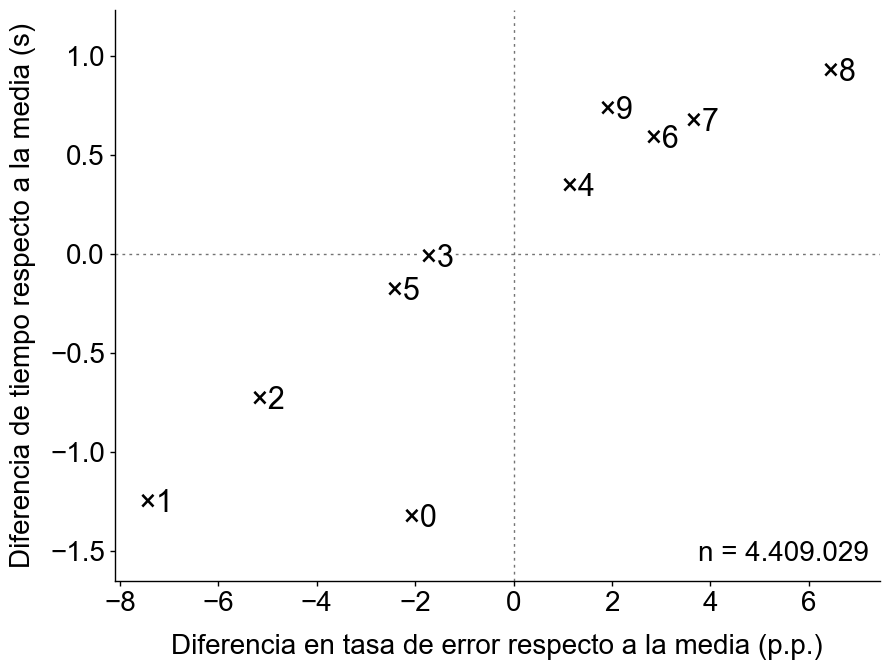


Plot -> descriptive\plots\a998_table_difficulty_map_second.png (+ .pdf)


In [4]:
LABEL_SIZE = 22
AXIS_TITLE_SIZE = 20   # nom dels eixos, una mica més petit
TICK_SIZE = 20             # numeros dels ticks
N_SIZE = 20                # la n

# --- difficulty map per taula: error i temps relatius a la seva edat --------
# [... mateix docstring que ja tenies, sense canvis ...]
from matplotlib import font_manager
import matplotlib as mpl

MODE = "second"

FONT_PREF = ["Helvetica", "Helvetica Neue", "Arial", "Liberation Sans",
             "Nimbus Sans", "Calibri", "DejaVu Sans"]
_installed = {f.name for f in font_manager.fontManager.ttflist}
FONT = next((f for f in FONT_PREF if f in _installed), "DejaVu Sans")
mpl.rcParams["font.family"] = FONT
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

cells_t = agg_all[(agg_all["definition"] == MODE)
                  & (agg_all["n"] >= MIN_N)
                  & (agg_all["classroom_course_age"].isin(AGES))].copy()
cells_t["error_pct"] = cells_t["error_rate"] * 100

ref_age = (cells_t.groupby("classroom_course_age")
                  .agg(mitjana_error=("error_pct", "mean"),
                       mitjana_rt=("mean_rt", "mean")))
cells_t = cells_t.join(ref_age, on="classroom_course_age")
cells_t["relative_error"] = cells_t["error_pct"] - cells_t["mitjana_error"]
cells_t["relative_rt"] = cells_t["mean_rt"] - cells_t["mitjana_rt"]

diff_map = (cells_t.groupby("mult_table")
                   .agg(relative_error=("relative_error", "mean"),
                        relative_rt=("relative_rt", "mean"),
                        edats=("classroom_course_age", "nunique"),
                        n=("n", "sum"))
                   .sort_values("relative_error", ascending=False))

print(f"[{MODE}] referencia de cada edat (mitjana entre taules, sense ponderar):")
print(ref_age.round(2).to_string())
print(f"\n[{MODE}] dificultat relativa per taula (edats {AGES[0]}-{AGES[-1]}, "
      "positiu = mes dificil que la seva edat):")
print(diff_map.round(3).to_string())
print(f"\nOrdre per ERROR : {' > '.join('×%d' % t for t in diff_map.index)}")
print(f"Ordre per TEMPS : "
      f"{' > '.join('×%d' % t for t in diff_map.sort_values('relative_rt', ascending=False).index)}")
print(f"Correlacio error-temps entre taules: r = "
      f"{np.corrcoef(diff_map['relative_error'], diff_map['relative_rt'])[0, 1]:.3f}")

# --- scatter: un punt per taula --------------------------------------------
fig, ax = plt.subplots(figsize=(9.0, 6.8))   # ampliat respecte al 5.5x4.5 original
                                             # perque amb FONT_BASE=24 el text
                                             # de les fletxes i la n es tallava

x = diff_map["relative_error"].to_numpy()
y = diff_map["relative_rt"].to_numpy()
tables = diff_map.index.to_numpy()

ax.axvline(0, color="0.45", lw=1, ls=(0, (2, 3)), zorder=1)
ax.axhline(0, color="0.45", lw=1, ls=(0, (2, 3)), zorder=1)

# Mantinc l'scatter invisible com al teu codi original
ax.scatter(x, y, s=0)

# --- etiquetes ×N -----------------------------------------------------------
# ×3 i ×5 estan molt junts.
# NO canviem les coordenades reals; només desplacem les etiquetes.
# A més, hi dibuixem un punt negre real i una línia de connexió més visible.

LABEL_OFFSETS = {
    3: (24, 16),      # més a la dreta i amunt
    5: (-24, -16),    # més a l'esquerra i avall
}

table_text_artists = []

for t, xi, yi in zip(tables, x, y):

    if t in LABEL_OFFSETS:
        dx, dy = LABEL_OFFSETS[t]

        ann = ax.annotate(
            f"×{t}",
            xy=(xi, yi),                # coordenada REAL
            xytext=(dx, dy),            # només es mou l'etiqueta
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=LABEL_SIZE,
            color="black",
            zorder=6,
            bbox=dict(facecolor="white", edgecolor="none", pad=0.2),
        )
        table_text_artists.append((t, ann))

    else:
        txt = ax.text(xi, yi, f"×{t}",
                      ha="center", va="center",
                      fontsize=LABEL_SIZE, color="black", zorder=3)
        table_text_artists.append((t, txt))

ax.margins(x=0.06, y=0.14)
fig.canvas.draw()

# Comprovem només les etiquetes de les taules
renderer = fig.canvas.get_renderer()
boxes = [(t, artist.get_window_extent(renderer=renderer))
         for t, artist in table_text_artists]
overlaps = [f"×{a} i ×{b}" for i, (a, ba) in enumerate(boxes)
            for b, bb in boxes[i + 1:] if ba.overlaps(bb)]
print("Etiquetes solapades: " + (", ".join(overlaps) if overlaps else "cap"))

# --- eixos ------------------------------------------------------------------
ax.set_xlabel("Diferencia en tasa de error respecto a la media (p.p.)",
              fontsize=AXIS_TITLE_SIZE, labelpad=12)
ax.set_ylabel("Diferencia de tiempo respecto a la media (s)",
              fontsize=AXIS_TITLE_SIZE, labelpad=10)

ax.tick_params(axis="both", labelsize=TICK_SIZE, colors="black", width=1)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1)
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")

n_real = agg_all[(agg_all["definition"] == "first")
                 & (agg_all["classroom_course_age"].isin(AGES))]["n"].sum()
n_total = f"{n_real:,}".replace(",", ".")
ax.text(0.985, 0.025, f"n = {n_total}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=N_SIZE, color="black")

# Fons: el rectangle dels EIXOS (ax.patch) va BLANC i opac; el de la FIGURA
# (fig.patch), que es tot el que l'envolta (marges, eixos, n...), transparent.
# Son dues coses diferents -- per aixo ja NO es fa servir savefig(transparent=
# True), que buidaria els dos alhora i deixaria el requadre transparent tambe.
ax.set_facecolor("white")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.patch.set_facecolor("none")
    fig.savefig(HERE / "plots" / f"a998_table_difficulty_map_{MODE}.{ext}",
                dpi=500, bbox_inches="tight", facecolor="none")

plt.show()
print(f"\nPlot -> {(HERE / 'plots' / f'a998_table_difficulty_map_{MODE}.png').relative_to(ROOT)} (+ .pdf)")

[second] Taula del X = X es estrictament el segon factor (7x8 si, 8x7 no)
Caselles (taula x edat) amb n < 200, fora de la figura: ×0 a 8 anys (n = 29), ×1 a 8 anys (n = 18)

Referencia de cada panell (mitjana entre les taules presents, sense ponderar):
                      mitjana_error  mitjana_rt  taules
classroom_course_age                                   
8                             38.06        6.62       8
9                             19.48        4.90      10
10                            16.29        4.41      10
11                            12.62        3.92      10
12                            10.95        3.69      10
13                             8.68        3.33      10
14                             7.65        3.14      10
15                             7.00        3.05      10

Ordre per ERROR dins de cada edat (mes dificil -> mes facil) i dispersio:
  8 anys (8 taules): ×8 > ×5 > ×4 > ×7 > ×6 > ×9 > ×2 > ×3   | rang error  18.8 pp | rang temps 2.15 s | r error

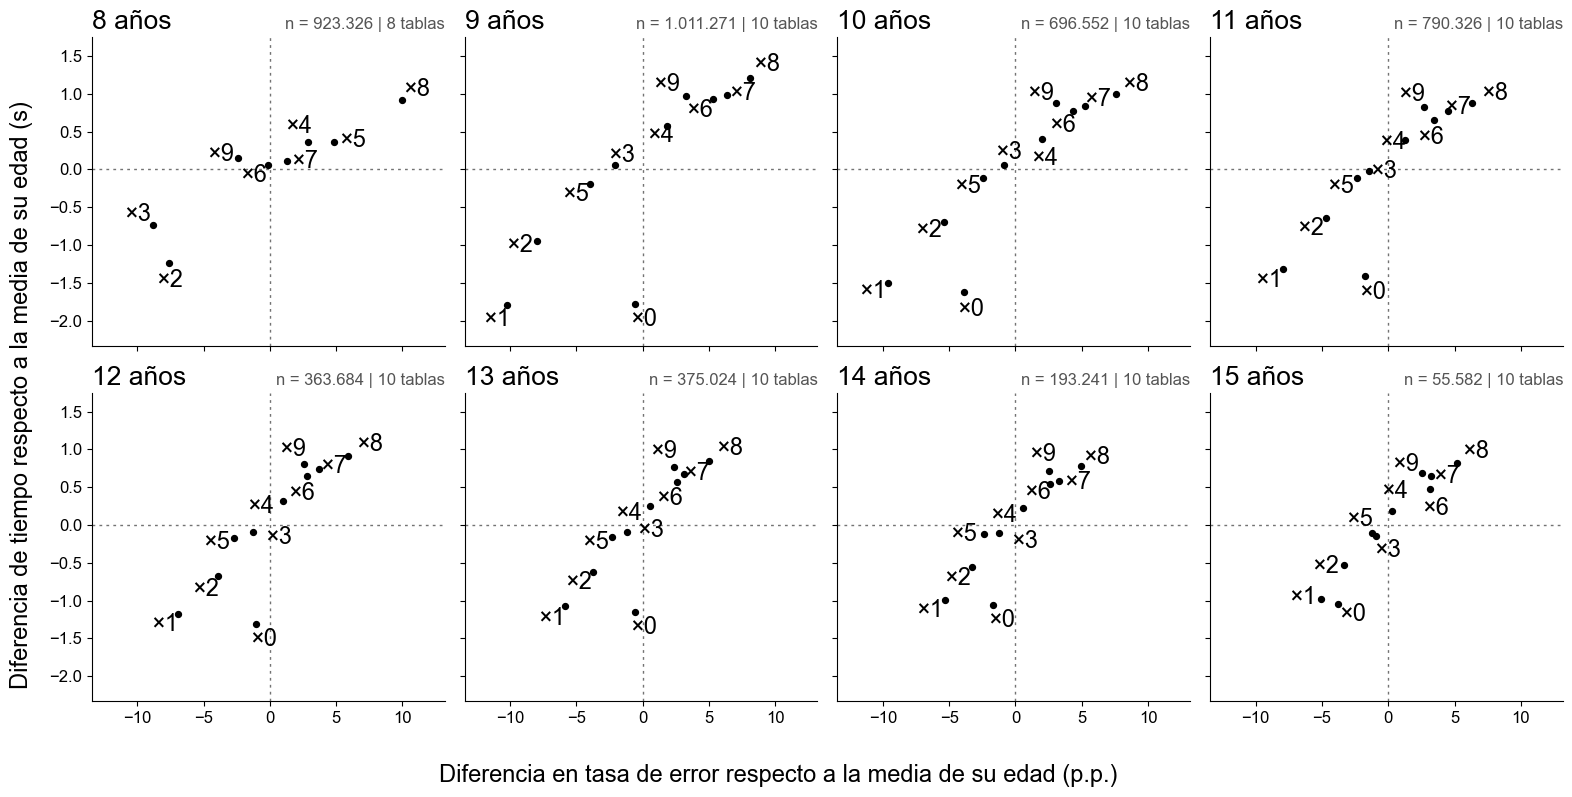

Plot -> descriptive\plots\a998_table_difficulty_map_by_age_second.png (+ .pdf)



In [5]:
# --- THE SAME FIGURE AS ABOVE, BUT SPLIT BY AGE -----------------------------
# Asked for by Maria (2026-08-24). The difficulty map of the previous cell puts
# ONE point per table: the mean, across ages, of its relative position. This is
# the SAME figure -- same axes, same arithmetic, same ×N labels -- but unfolded
# into one panel per age, without averaging across ages. It is how you see
# whether the order and the distances between tables move with the grade, or
# whether the single-point map already sums it all up.
#
# THE AXES ARE THE CURRENT ONES, nothing changed:
#   x = error rate of the table MINUS the mean across tables of ITS OWN age
#       (percentage points)
#   y = mean_rt of the table MINUS the mean across tables of ITS OWN age
#       (seconds, correct answers only)
# Both references are UNWEIGHTED means across tables, computed age by age,
# exactly as in the map cell; so every panel has its own origin and (0, 0) IS
# the mean of that age. The demeaning is not cosmetic: raw levels fall from
# 38.7% to 7.0% error and from 6.7 s to 3.1 s between 8 and 15, so without
# removing the mean the panels would only draw the age and not the relative
# position of each table.
#
# DEFINITION: inherited from the map cell just above (MODE), which is the one
# you are looking at. To change it, MODE_AGE = "either" | "first" | "second" on
# the line below.
#
# SHARED SCALE across panels: the distances between tables have to be comparable
# across ages, and that is exactly what shows -- at 8 the tables are spread out
# and at 15 they are all bunched together. The per-panel autoscaled version (the
# one whose file ended in _zoom) was dropped on 2026-08-25: it read the order up
# close, but its distances were NOT comparable across ages, which is the whole
# point of the figure. No limit is ever set by hand.
#
# COVERAGE: n >= MIN_N is filtered cell by cell, so a panel can have fewer than
# 10 tables (at 8 there is no ×0 -- curriculum gap, Decision #4). Which cells
# drop out and how many tables each panel keeps are printed.
# CAREFUL with the n of the 'either' definition: one attempt (8×7) counts for
# table ×8 AND for ×7, so summing n across tables would double the sample; the n
# of each panel is always computed with the 'first' definition, which splits the
# sample one attempt -> one table.
MODE_AGE = MODE           # inherits the definition of the map cell above
N_COLS_AGE = 4            # 8 ages -> 2 x 4 grid
PANEL_SIDE_AGE = 4.0      # inches per panel
LABEL_SIZE_AGE = 17       # the ×N labels
TICK_SIZE_AGE = 12

cells_age = agg_all[(agg_all["definition"] == MODE_AGE)
                    & (agg_all["classroom_course_age"].isin(AGES))].copy()
cells_age["error_pct"] = cells_age["error_rate"] * 100

thin = cells_age[cells_age["n"] < MIN_N]
print(f"[{MODE_AGE}] {DEFINITIONS[MODE_AGE]}")
print(f"Caselles (taula x edat) amb n < {MIN_N}, fora de la figura: "
      + (", ".join(f"×{int(r.mult_table)} a {int(r.classroom_course_age)} anys"
                   f" (n = {int(r.n)})" for r in thin.itertuples()) or "cap"))
cells_age = cells_age[cells_age["n"] >= MIN_N]

# Reference of each age: unweighted mean across tables (same as the map)
ref_age_panels = (cells_age.groupby("classroom_course_age")
                           .agg(mitjana_error=("error_pct", "mean"),
                                mitjana_rt=("mean_rt", "mean"),
                                taules=("mult_table", "nunique")))
cells_age = cells_age.join(ref_age_panels, on="classroom_course_age")
cells_age["relative_error"] = cells_age["error_pct"] - cells_age["mitjana_error"]
cells_age["relative_rt"] = cells_age["mean_rt"] - cells_age["mitjana_rt"]
print("\nReferencia de cada panell (mitjana entre les taules presents, sense ponderar):")
print(ref_age_panels.round(2).to_string())

# What is in each panel: the order of the tables, how spread out they are, and
# whether the two axes still say the same thing (the r between error and time
# ACROSS tables, the same number the map cell prints but computed age by age).
print(f"\nOrdre per ERROR dins de cada edat (mes dificil -> mes facil) i dispersio:")
for a in AGES:
    d = cells_age[cells_age["classroom_course_age"] == a].sort_values(
        "relative_error", ascending=False)
    r = np.corrcoef(d["relative_error"], d["relative_rt"])[0, 1]
    print(f"  {a} anys ({len(d)} taules): "
          + " > ".join(f"×{int(t)}" for t in d["mult_table"])
          + f"   | rang error {d['relative_error'].max() - d['relative_error'].min():5.1f} pp"
          + f" | rang temps {d['relative_rt'].max() - d['relative_rt'].min():4.2f} s"
          + f" | r error-temps {r:.3f}")

print("\nPosicio relativa en ERROR (pp), edat x taula:")
print(cells_age.pivot(index="classroom_course_age", columns="mult_table",
                      values="relative_error").round(2).to_string())
print("\nPosicio relativa en TEMPS (s), edat x taula:")
print(cells_age.pivot(index="classroom_course_age", columns="mult_table",
                      values="relative_rt").round(2).to_string())


def _label_offsets(x, y, ax, pad=13.0):
    """Offset (in points) of each ×N label: every point pushes the label away
    from the other points, weighted 1/d^2 and in coordinates normalised by the
    axis ranges (otherwise an axis in seconds and one in percentage points
    cannot be compared). Same criterion as the poster cell; here it has to be
    generic, because each age has a different set of tables and hand-made
    offsets for ×3 and ×5 would not do for the 8 panels."""
    (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
    xs = (x - x0) / max(x1 - x0, 1e-12)
    ys = (y - y0) / max(y1 - y0, 1e-12)
    out = []
    for i in range(len(x)):
        vx = vy = 0.0
        for j in range(len(x)):
            if i == j:
                continue
            dx, dy = xs[i] - xs[j], ys[i] - ys[j]
            d2 = dx * dx + dy * dy
            if d2 < 1e-12:
                dx, dy, d2 = 0.01, 0.01, 2e-4     # points exactly on top of each other
            w = 1.0 / d2
            norm = np.sqrt(d2)
            vx += w * dx / norm
            vy += w * dy / norm
        m = np.hypot(vx, vy)
        out.append((pad * vx / m, pad * vy / m) if m > 1e-12 else (0.0, pad))
    return out


def _spread_labels(fig, arts, offs, step=2.5, n_iter=24):
    """Second pass over the ×N labels: the repulsion of `_label_offsets` does not
    guarantee that two labels do not touch (the tables fall almost in a line, so
    ×7/×8 or ×3/×4 end up pushed the same way). Here they are separated by
    looking at the real text boxes, in pixels, moving them apart a little on each
    iteration. `arts` are the annotation artists and `offs` their (dx, dy)
    offsets in points, modified in place. Returns False if any pair is still
    overlapping when the iterations run out -- the caller says so, it is never
    hidden."""
    def _boxes():
        fig.canvas.draw()
        rend = fig.canvas.get_renderer()
        return [art.get_window_extent(renderer=rend) for art in arts]

    for _ in range(n_iter):
        boxes = _boxes()
        moved = False
        for i in range(len(arts)):
            for j in range(i + 1, len(arts)):
                if not boxes[i].overlaps(boxes[j]):
                    continue
                moved = True
                ci = np.array([boxes[i].x0 + boxes[i].width / 2,
                               boxes[i].y0 + boxes[i].height / 2])
                cj = np.array([boxes[j].x0 + boxes[j].width / 2,
                               boxes[j].y0 + boxes[j].height / 2])
                v = ci - cj
                if np.hypot(*v) < 1e-9:
                    v = np.array([1.0, 1.0])
                v = step * v / np.hypot(*v)      # points per iteration
                offs[i] = (offs[i][0] + v[0], offs[i][1] + v[1])
                offs[j] = (offs[j][0] - v[0], offs[j][1] - v[1])
                arts[i].set_position(offs[i])
                arts[j].set_position(offs[j])
        if not moved:
            return True
    boxes = _boxes()
    return not any(boxes[i].overlaps(boxes[j])
                   for i in range(len(boxes)) for j in range(i + 1, len(boxes)))


def plot_map_by_age():
    n_rows = int(np.ceil(len(AGES) / N_COLS_AGE))
    fig, axes = plt.subplots(n_rows, N_COLS_AGE, sharex=True,
                             sharey=True, squeeze=False,
                             figsize=(PANEL_SIDE_AGE * N_COLS_AGE,
                                      PANEL_SIDE_AGE * n_rows))
    overlaps_all = []
    for k, a in enumerate(AGES):
        ax = axes[k // N_COLS_AGE][k % N_COLS_AGE]
        d = cells_age[cells_age["classroom_course_age"] == a].sort_values("mult_table")
        x = d["relative_error"].to_numpy()
        y = d["relative_rt"].to_numpy()
        tables = d["mult_table"].to_numpy()

        ax.axvline(0, color="0.45", lw=1, ls=(0, (2, 3)), zorder=1)
        ax.axhline(0, color="0.45", lw=1, ls=(0, (2, 3)), zorder=1)
        # A small real dot plus a shifted label: with 10 labels in a small panel,
        # putting the text on the coordinate itself (as the big map does) makes
        # them overlap. The dot marks the exact position; only the text moves.
        ax.scatter(x, y, s=18, color="black", zorder=3)
        ax.set_title(f"{a} años", fontsize=LABEL_SIZE_AGE + 2, loc="left")
        ax.tick_params(labelsize=TICK_SIZE_AGE)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        ax.margins(x=0.16, y=0.18)
        n_panel = int(agg_all[(agg_all["definition"] == "first")
                              & (agg_all["classroom_course_age"] == a)
                              & (agg_all["n"] >= MIN_N)]["n"].sum())
        # The n goes in the title, on the right: inside the panel it collided
        # with the ×0 and with the zero line depending on the age, and up here it
        # cannot collide with anything.
        ax.set_title(f"n = {n_panel:,}".replace(",", ".") + f" | {len(d)} tablas",
                     fontsize=TICK_SIZE_AGE, color="#555555", loc="right")

        fig.canvas.draw()      # the final limits are needed to normalise
        offs = list(_label_offsets(x, y, ax))
        arts = [ax.annotate(f"×{t}", xy=(xi, yi), xytext=off,
                            textcoords="offset points", ha="center", va="center",
                            fontsize=LABEL_SIZE_AGE, color="black", zorder=5)
                for t, xi, yi, off in zip(tables, x, y, offs)]
        if not _spread_labels(fig, arts, offs):
            overlaps_all.append(f"{a} anys")

    for k in range(len(AGES), n_rows * N_COLS_AGE):
        axes[k // N_COLS_AGE][k % N_COLS_AGE].set_visible(False)

    print("Panells amb etiquetes encavalcades: "
          + (", ".join(overlaps_all) if overlaps_all else "cap"))

    fig.supxlabel("Diferencia en tasa de error respecto a la media de su edad (p.p.)",
                  fontsize=LABEL_SIZE_AGE)
    fig.supylabel("Diferencia de tiempo respecto a la media de su edad (s)",
                  fontsize=LABEL_SIZE_AGE)
    # rect: without this left margin the supylabel covers the minus sign of the
    # negative ticks in the first column.
    fig.tight_layout(rect=(0.02, 0.02, 1, 1))
    out = HERE / "plots" / f"a998_table_difficulty_map_by_age_{MODE_AGE}"
    for ext in ("png", "pdf"):
        fig.savefig(out.with_suffix(f".{ext}"), dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Plot -> {out.relative_to(ROOT)}.png (+ .pdf)\n")


plot_map_by_age()

In [6]:
# --- ranking: ordre descendent per error rate i per response time ----------
# Nomes una definicio ('first' i 'second' donarien basicament el mateix
# ordre per aquesta pregunta -- 'either' es l'unica que barreja els dos
# factors, aixi que la deixem fora d'aquest ranking puntual). Mitjana
# ponderada per n, totes les edats agrupades. Dues classificacions per
# separat (no es combinen en un sol score), per veure si "mes error" i "mes
# lent" son la mateixa taula o no.
MODE = "first"
d = agg_all[(agg_all["definition"] == MODE) & (agg_all["n"] >= MIN_N)]

summary = (d.groupby("mult_table")
             .apply(lambda g: pd.Series({
                 "n": g["n"].sum(),
                 "error_rate": np.average(g["error_rate"], weights=g["n"]),
                 "mean_rt": np.average(g["mean_rt"].fillna(0), weights=g["n_correct"].clip(lower=1)),
             }), include_groups=False))

print(f"[{MODE}] ordre descendent per ERROR RATE:")
print(summary.sort_values("error_rate", ascending=False)[["error_rate", "n"]].round(4))

print(f"\n[{MODE}] ordre descendent per RESPONSE TIME:")
print(summary.sort_values("mean_rt", ascending=False)[["mean_rt", "n"]].round(4))

[first] ordre descendent per ERROR RATE:
            error_rate         n
mult_table                      
8               0.2840  453811.0
7               0.2684  455857.0
6               0.2504  455936.0
9               0.2464  456607.0
4               0.2193  456730.0
3               0.1898  462446.0
5               0.1679  462078.0
2               0.1239  466782.0
0               0.0868  265401.0
1               0.0852  473358.0

[first] ordre descendent per RESPONSE TIME:
            mean_rt         n
mult_table                   
8            5.6471  453811.0
9            5.5226  456607.0
7            5.4006  455857.0
6            5.3863  455936.0
4            5.1374  456730.0
3            4.7257  462446.0
5            4.4773  462078.0
2            3.7707  466782.0
1            2.8624  473358.0
0            2.4716  265401.0


In [7]:
# =============================================================================
# Quin FET individual (a x b) es mes dificil? -- heatmaps per edat
# =============================================================================
# Grau mes fi que tot l'anterior: no per taula, sino per parella (factor_1,
# factor_2) exacta, tal com surt a `operation` (sense fusionar 8x7 amb 7x8 --
# per aixo la matriu no es simetrica; aixo deixa preparat, de franc, el terreny
# per la pregunta d'asimetria que vam ajornar).
#
# error_rate = mitjana de (Incorrect + Help), mateixa convencio que la resta
# del notebook.
# median_rt  = MEDIANA de statement_seconds_spent, nomes respostes CORRECTES
# (decisio presa amb Maria 2026-07-29: coherent amb rt_A998_answers.sql i amb
# el mean_rt de a998_table_difficulty_by_age.sql, pero mediana en lloc de
# mitjana perque aqui les caselles son mes petites i el RT te cua llarga).
SQL_PATH2 = HERE / "queries" / "a998_fact_heatmap_by_age.sql"

fact_df = cached_query(SQL_PATH2, CACHE_DIR)

print(f"Files: {len(fact_df):,} (factor_1 x factor_2 x edat) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
print(fact_df["n"].describe().round(1))

Files: 795 (factor_1 x factor_2 x edat) | cache -> descriptive\cache/
count      795.0
mean      5545.9
std       5410.9
min          1.0
25%       1933.0
50%       3766.0
75%       7627.0
max      32460.0
Name: n, dtype: float64


In [8]:
# --- llindar de mostra per aquest grau mes fi ------------------------------
# A nivell de fet (no de taula) les caselles son ~10x mes petites. Hi ha un
# salt net a les dades: 26 caselles amb n <= 7 (totes a edat 8, forats de
# curriculum -- Decisio #4, packs que no cobreixen aquella parella concreta)
# i despres tot salta a n >= 491. FACT_MIN_N = 100 talla exactament aqui.
FACT_MIN_N = 100

sparse_facts = fact_df[fact_df["n"] < FACT_MIN_N]
print(f"{len(sparse_facts)} / {len(fact_df)} caselles (factor_1 x factor_2 x edat) tenen n < {FACT_MIN_N}.")
print("Totes concentrades a:")
print(sparse_facts["classroom_course_age"].value_counts().sort_index())

23 / 795 caselles (factor_1 x factor_2 x edat) tenen n < 100.
Totes concentrades a:
classroom_course_age
8    23
Name: count, dtype: int64


In [9]:
# --- fact cells with enough sample: the input of the ranking below ----------
valid_fact = fact_df[fact_df["n"] >= FACT_MIN_N]


In [10]:
# --- ranking per edat: quines operacions concretes son les mes dificils ----
# Mateixes dades que els heatmaps (caselles amb n >= FACT_MIN_N nomes), pero
# en forma de llista ordenada en lloc de matriu -- per llegir directament
# "les 10 operacions mes dificils a edat X" sense haver de buscar-les al mapa
# de colors. Dues llistes per edat (no combinades en un sol score): la mes
# errada i la mes lenta poden no coincidir (com ja vam veure a nivell de
# taula amb 9 vs 7/6).
TOP_N = 10

valid_fact = fact_df[fact_df["n"] >= FACT_MIN_N].copy()
valid_fact["operation"] = valid_fact["factor_1"].astype(str) + "×" + valid_fact["factor_2"].astype(str)

for age in range(8, 16):
    d = valid_fact[valid_fact["classroom_course_age"] == age]
    print(f"\n=========== edat {age} ===========")

    print(f"Top {TOP_N} per ERROR RATE:")
    print(d.sort_values("error_rate", ascending=False)
           [["operation", "error_rate", "n"]]
           .head(TOP_N)
           .to_string(index=False))

    print(f"\nTop {TOP_N} per RESPONSE TIME (mediana, correctes):")
    print(d.sort_values("median_rt", ascending=False)
           [["operation", "median_rt", "n_correct"]]
           .head(TOP_N)
           .to_string(index=False))


=========== edat 8 ===========
Top 10 per ERROR RATE:
operation  error_rate     n
      6×8      0.6422 12134
      7×8      0.6378 12436
      8×8      0.5934 12490
      8×6      0.5809  3799
      7×4      0.5679 12309
      7×5      0.5593 30193
      4×8      0.5559 12244
      8×4      0.5514 12271
      8×5      0.5416 30118
      9×4      0.5401 12324

Top 10 per RESPONSE TIME (mediana, correctes):
operation  median_rt  n_correct
      6×8     8.2330       4341
      7×4     8.0650       5319
      9×4     7.8340       5668
      3×8     7.8150       6279
      8×6     7.6215       1592
      7×5     7.5340      13307
      4×8     7.4330       5437
      4×7     7.3335       2018
      8×4     7.2510       5505
      6×4     7.1660       5961

=========== edat 9 ===========
Top 10 per ERROR RATE:
operation  error_rate     n
      8×6      0.4234 12652
      6×8      0.4094 12854
      7×8      0.3954 13066
      8×8      0.3918 13135
      8×7      0.3914 12949
      7×7     

Sol de mesura (mitjana de les 5 mes facils): 3.º 12.5% -> 6.º 3.6%
Les 5 mes dificils a 6.º: 29.8% -> 26.2 pp per sobre del sol


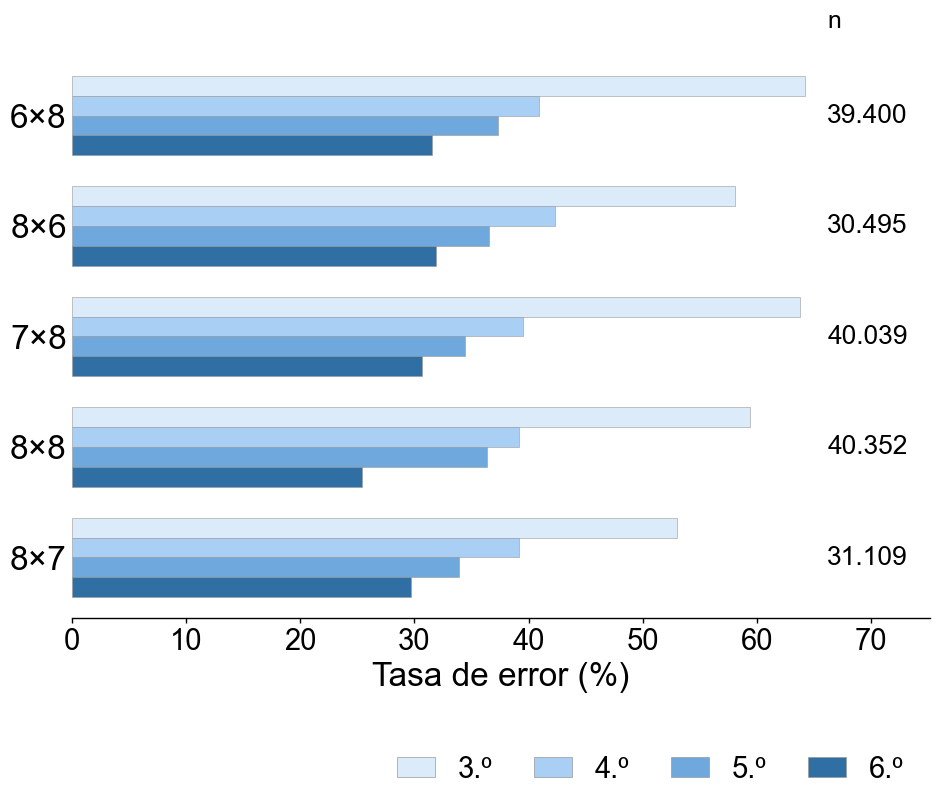


Error rate (%) per operacio x curs:
classroom_course_age   3.º   4.º   5.º   6.º
operation                                   
6×8                   64.2  40.9  37.3  31.5
8×6                   58.1  42.3  36.5  31.9
7×8                   63.8  39.5  34.4  30.6
8×8                   59.3  39.2  36.4  25.4
8×7                   53.0  39.1  33.9  29.7
1×8                   15.1   6.1   5.9   3.7
1×4                   14.1   5.8   5.7   3.3
1×3                   11.6   5.9   6.2   4.1
1×7                   11.3   5.3   4.9   3.4
1×6                   10.2   5.0   5.3   3.6


In [11]:
# --- 5 mes dificils vs 5 mes facils, una barra fina per edat (3r-6e) ---------
# Combina els dos extrems en un sol grafic per comparar magnituds, amb una
# barra fina per edat dins de cada operacio i la rampa de color blau clar (3r) ->
# blau fosc (6e). Serveix per veure dues coses alhora: quines operacions son
# dificils i quant baixa cada una amb el curs. Els percentatges es llegeixen de
# l'eix, no hi ha etiqueta a cada barra; la taula completa s'imprimeix a sota
# per al peu de figura.
#
# La n va en columna a la dreta, una per operacio (suma dels cursos dibuixats),
# amb capçalera "n (intentos)" -- una columna de numeros sense dir que son no es
# llegeix.
#
# ORDRE DINS DEL GRUP: 3r a dalt, 6e a baix, aixi la millora es llegeix com una
# escala que baixa. Barres separades (no encaixades), o sigui que no hi ha cap
# oclusio: la no-monotonia es veu. I n'hi ha: a les cinc operacions x1, 5e es
# lleugerament PITJOR que 4t (+0,3 a +1,2 pp). Amb barres encaixades per edat
# aquella vora quedaria tapada; aixi es veu.
#
# SOL DE MESURA: fora del grafic (decisio de Maria 2026-08-11), pero el numero
# es segueix imprimint perque cal per al peu de figura. L'error rate d'A998 no
# arriba mai a zero: el grup facil marca ~12% a 6e i ~34% a 3r, amb errors de RT
# mediana 0,9 s i statement_idx mitja 27,8 sobre ~30 -- teclejar de pressa al
# final del pack, no aritmetica. El 37% de les dificils a 6e s'ha de llegir
# contra aquest sol, tant si la linia hi es com si no.
#
# COMPTE amb el bloc de 3r: 74% contra 39% a 6e, i a 3r el sol ja es del 34%
# (1x8 al 37,5%!). La barra blanca mesura sobretot "acaben de trobar les taules
# + corren al final del pack" (Decisio #4, packs diferents per edat), no
# dificultat del fet. Per aixo tambe es desa una versio nomes amb 4t-6e.
from matplotlib.patches import Patch

AGE_GRADE = {8: "3.º", 9: "4.º", 10: "5.º", 11: "6.º"}   # d_courses ES_2025: 8=PE3 ... 11=PE6

# Mida de lletra des d'un sol numero, com a speed_precision.ipynb: puja
# FONT_BASE i creix tot. La columna de la n va mes petita a proposit -- a 22 pt
# un "48.378" s'emporta una franja ampla del grafic i competeix amb el nom de
# l'operacio, que es el que s'ha de llegir primer.
FONT_BASE = 24

AGE_COLOR = {
    8:  "#DCEBFA",
    9:  "#A9CFF5",
    10: "#6FA8DC",
    11: "#2F6FA3",
}

EDGE_COLOR = "0.6"      # bar outline: the same grey as the legend patches

# `cells` = one row per (ordered operation a×b, grade). Rebuilt on 2026-08-25,
# after the cell that defined it was deleted. Only operations present at ALL
# FOUR grades enter, so the ranking is not decided by a fact age 8 never saw
# (the ×1 facts written n×1, and 0×0, have no cell at 8 -- Decision #4).
# Checked against the output this cell had already stored: same 5 hardest, same
# 5 easiest, same table to the decimal.
cells = (valid_fact[valid_fact["classroom_course_age"].isin(AGE_GRADE)]
         .assign(operation=lambda d: d["factor_1"].astype(str) + "×"
                                     + d["factor_2"].astype(str)))
cells = cells[cells.groupby("operation")["classroom_course_age"]
                   .transform("nunique") == len(AGE_GRADE)]

K = 5                                                    # 5 dificils + 5 facils
ranked = (cells.groupby("operation")["error_rate"].mean() * 100).sort_values(ascending=False)
HARD, EASY = list(ranked.head(K).index), list(ranked.tail(K).index)

by_age = cells.pivot(index="operation", columns="classroom_course_age",
                     values="error_rate") * 100
FLOOR_11 = by_age.loc[EASY, 11].mean()
FLOOR_8 = by_age.loc[EASY, 8].mean()
print(f"Sol de mesura (mitjana de les {K} mes facils): 3.º {FLOOR_8:.1f}% -> 6.º {FLOOR_11:.1f}%")
print(f"Les {K} mes dificils a 6.º: {by_age.loc[HARD, 11].mean():.1f}% "
      f"-> {by_age.loc[HARD, 11].mean() - FLOOR_11:.1f} pp per sobre del sol")


def plot_extremes(ages, fname):
    """Una fila per operacio, una barra fina per edat. `ages` de gran a petit."""
    rows = HARD
    GAP = 0.9                                            # separacio entre blocs
    slot = {op: i + (GAP if i >= K else 0) for i, op in enumerate(rows)}
    bar_h = 0.72 / len(ages)
    offs = {a: (len(ages) - 1) / 2 * bar_h - i * bar_h    # primera edat a dalt
            for i, a in enumerate(ages)}
    fig, ax = plt.subplots(figsize=(9.5, 8.5))   # llenc mes gran per a la lletra 22
    # Fons: el rectangle dels EIXOS (ax.patch) va BLANC i opac; el de la FIGURA
    # (fig.patch), que es tot el que l'envolta, transparent. Son dues coses
    # diferents -- per aixo NO es fa servir savefig(transparent=True), que
    # buidaria els dos alhora i deixaria el requadre transparent tambe.
    ax.set_facecolor("white")
    n_by_age = cells.pivot(index="operation", columns="classroom_course_age", values="n")
    x_n = by_age.loc[rows, ages[0]].max() * 1.03          # columna fixa per a la n
    for op in rows:
        for a in ages:
            ax.barh(-slot[op] + offs[a], by_age.loc[op, a], height=bar_h,
                    color=AGE_COLOR[a], edgecolor=EDGE_COLOR, linewidth=0.4,
                    zorder=2)
        n_op = f"{int(n_by_age.loc[op, ages].sum()):,}".replace(",", ".")
        ax.text(x_n, -slot[op], n_op, va="center", ha="left",
                fontsize=FONT_BASE - 5, color="black")
    ax.text(x_n, -slot[rows[0]] + 0.75    ,"n", va="bottom", ha="left",
            fontsize=FONT_BASE - 6, color="black")
    ax.set_yticks([-slot[op] for op in rows])
    ax.set_yticklabels(rows, fontsize=FONT_BASE)
    ax.set_xlabel("Tasa de error (%)", fontsize=FONT_BASE)
    ax.tick_params(axis="x", labelsize=FONT_BASE - 3, colors="black", width=1)
    ax.tick_params(axis="y", length=0, colors="black")
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)
    ax.xaxis.label.set_color("black")
    ax.margins(x=0.17, y=0.04)   # espai per a la columna de la n
    ax.legend(handles=[Patch(facecolor=AGE_COLOR[a], edgecolor="0.6", lw=0.5,
                             label=AGE_GRADE[a]) for a in ages],
              frameon=False, fontsize=FONT_BASE - 3, ncol=len(ages), loc="lower right",
              bbox_to_anchor=(1.0, -0.34), handlelength=1.3, columnspacing=1.4)
    # -0.34 i no -0.16: a mida 22 la llegenda queia justa damunt de "Tasa de
    # error (%)" i es solapaven. Ara va per sota de l'etiqueta de l'eix.
    fig.tight_layout()
    # Nomes el fons de la FIGURA es transparent (marges, eixos, llegenda); el
    # rectangle interior ja s'ha pintat de blanc a dalt amb set_facecolor.
    fig.patch.set_facecolor("none")
    for ext in ("png", "pdf"):
        fig.savefig(HERE / "plots" / f"{fname}.{ext}", dpi=300,
                    bbox_inches="tight", facecolor="none")
    plt.show()

plot_extremes([8, 9, 10, 11], f"a998_top{K}_bottom{K}_by_age_3o6o")

print("\nError rate (%) per operacio x curs:")
print(by_age.loc[HARD + EASY].rename(columns=AGE_GRADE).round(1).to_string())

Caselles amb n >= 100: 772 | 0 sense median_rt (cap resposta correcta) -> fora del scatter
Caselles dibuixades: 772 | edats 8-15
              caselles
familia               
amb 0              133
amb 5              127
quadrats a×a        71
resta              441

Correlació error_rate vs median_rt per edat (totes les caselles | sense els fets amb 0):
      caselles  pearson  spearman  caselles_sense_0  pearson_sense_0  spearman_sense_0
edat                                                                                  
8           72    0.907     0.902                72            0.907             0.902
9          100    0.798     0.754                81            0.920             0.943
10         100    0.871     0.793                81            0.913             0.929
11         100    0.858     0.759                81            0.923             0.942
12         100    0.838     0.749                81            0.900             0.923
13         100    0.851     0.722 

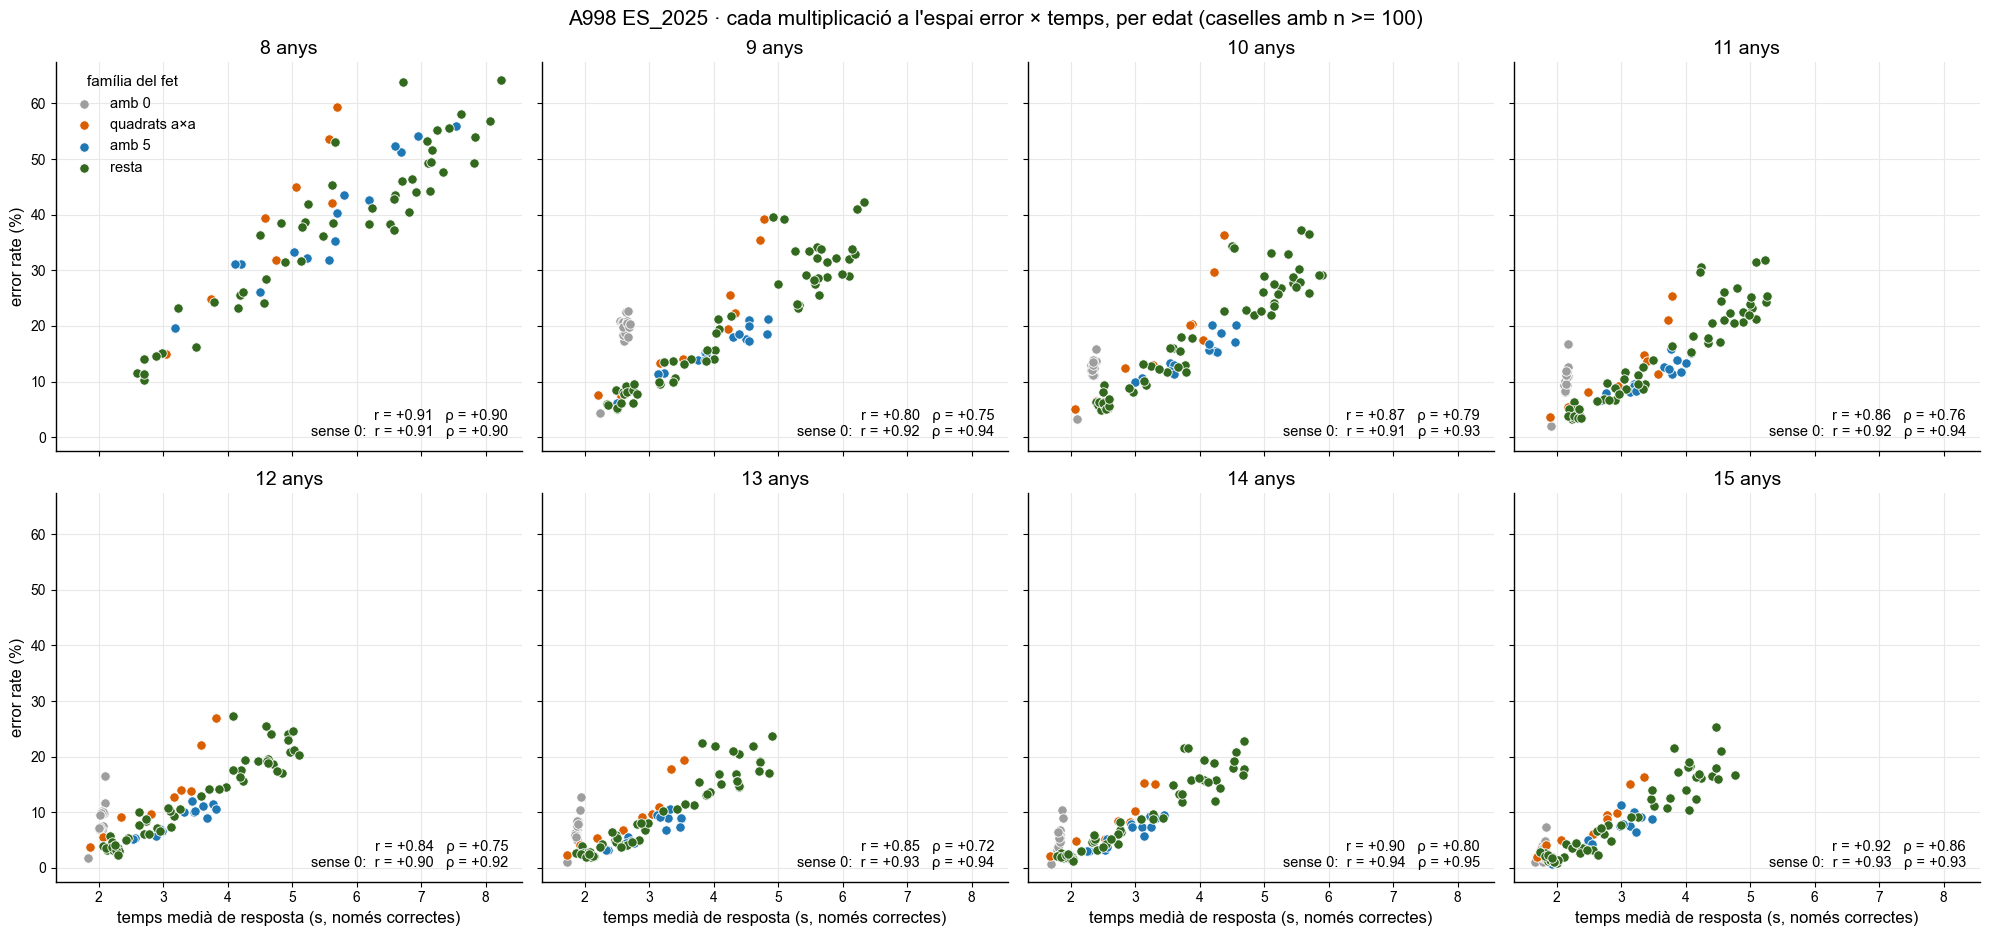


Plot -> descriptive\plots\a998_fact_error_vs_temps_per_edat.png (+ .pdf)

Forest plot: edats 9-15 | fora [8] (cap casella amb 0, les dues sèries coincidirien per construcció)


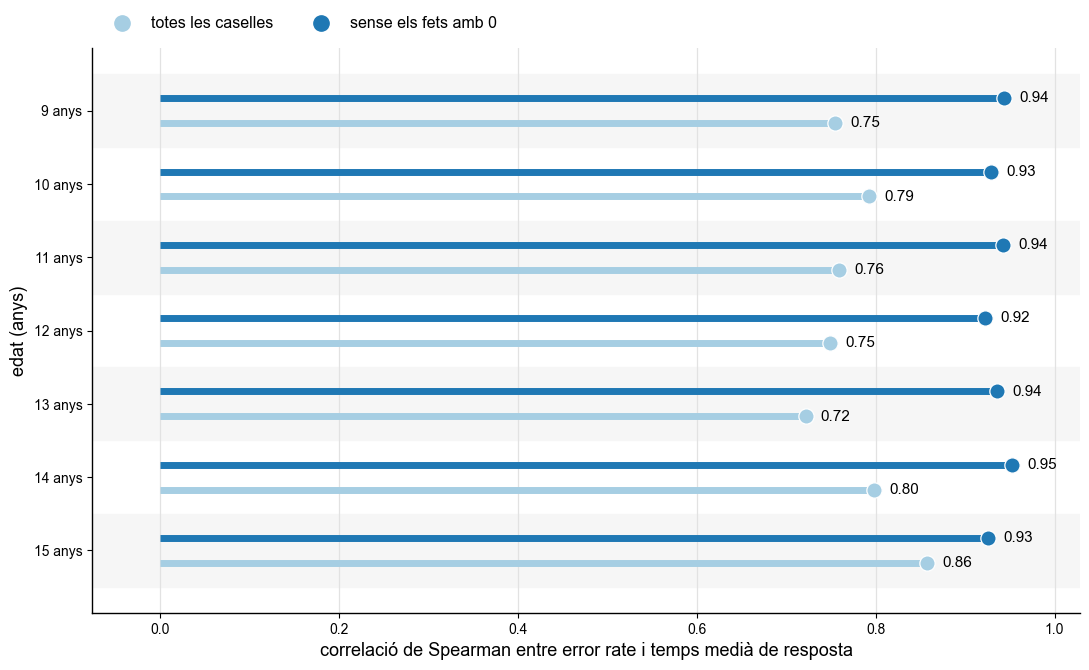

Plot -> descriptive\plots\a998_fact_error_temps_correlacions_forest_spearman.png (+ .pdf)
Spearman: 9: 0.75 / 0.94 · 10: 0.79 / 0.93 · 11: 0.76 / 0.94 · 12: 0.75 / 0.92 · 13: 0.72 / 0.94 · 14: 0.80 / 0.95 · 15: 0.86 / 0.93   (totes / sense 0)


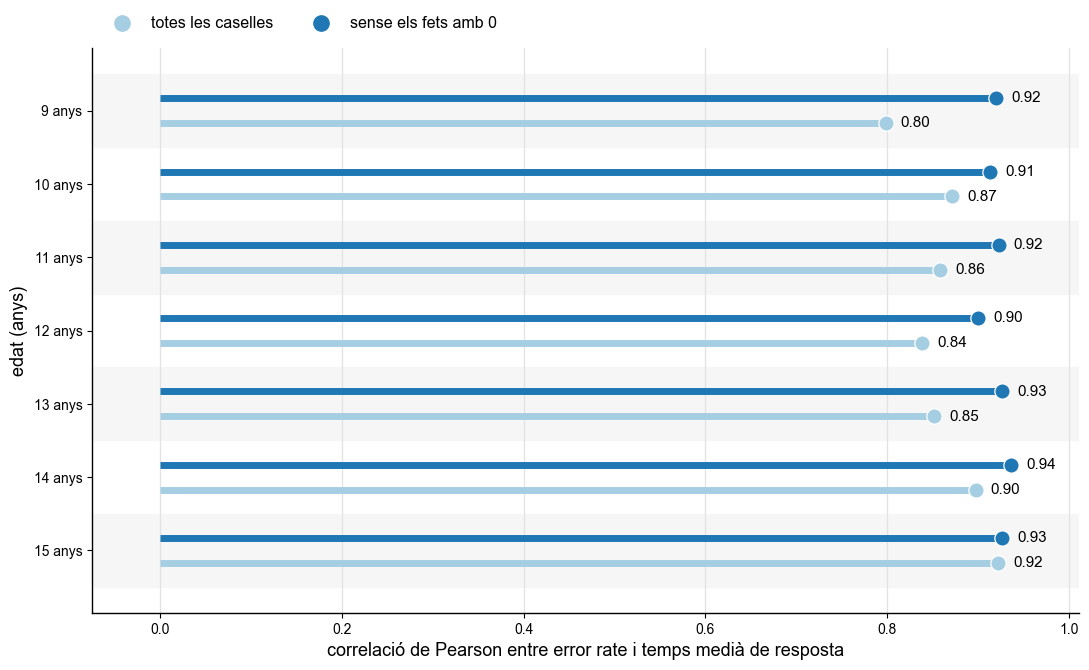

Plot -> descriptive\plots\a998_fact_error_temps_correlacions_forest_pearson.png (+ .pdf)
Pearson: 9: 0.80 / 0.92 · 10: 0.87 / 0.91 · 11: 0.86 / 0.92 · 12: 0.84 / 0.90 · 13: 0.85 / 0.93 · 14: 0.90 / 0.94 · 15: 0.92 / 0.93   (totes / sense 0)


In [12]:
# =============================================================================
# Cada FET (a × b) a l'espai ERROR × TEMPS, per edat  +  Pearson i Spearman
# =============================================================================
# Un punt per multiplicació: x = median_rt (mediana de segons, NOMÉS respostes
# correctes), y = error_rate en %. Les mateixes dades dels heatmaps
# (`fact_df`, de queries/a998_fact_heatmap_by_age.sql) i el mateix llindar per
# casella (n >= FACT_MIN_N): aquí només es canvia la forma de mirar-les -- el
# heatmap posa a × b als eixos i el color fa de valor; això posa els dos valors
# als eixos i deixa a × b com a etiqueta.
#
# NO CAL QUERY NOVA: la query dels heatmaps ja retorna error_rate I median_rt
# per (factor_1, factor_2, classroom_course_age), i el parquet ja és a cache/.
#
# QUÈ ES DIBUIXA I QUÈ NO
#   * 3 caselles no tenen median_rt (cap resposta correcta) -> fora del scatter,
#     però es diu quantes són. No es dibuixa cap recta ajustada: aquí només hi
#     ha valors observats i les dues correlacions que has demanat.
#   * Edat 8 té ~72 caselles i no 100: els packs de 8 anys (14/16/20) no cobreixen
#     totes les parelles (Decisió #4). És currículum, no un forat de dades.
#
# LES DUES CORRELACIONS ES DONEN DOS COPS: amb totes les caselles i SENSE ELS
# FETS AMB 0. Els fets amb 0 es responen ràpid però no són els que menys error
# tenen (el 0 com a element neutre es confon amb l'1: una part de les respostes
# errònies a 0×N són N), així que cauen fora de la relació i tiren la correlació
# avall -- sobretot la de Spearman, que és de rangs. Mesurat: a 9 anys
# ρ = +0,75 amb tots i +0,94 sense els 0. Amb quin dels dos et quedes és una
# decisió teva; el codi imprimeix els dos i la figura els marca en gris.
# A 8 anys els dos números són idèntics: aquella edat no té CAP casella amb 0
# per sobre del llindar (els seus packs no en porten).
#
# CAVEAT que val per als dos números: el filtre de rapid-guessing del .sql és
# UNIDIRECCIONAL (només treu respostes errònies de menys d'1,2 s), així que pot
# només abaixar l'error_rate d'una casella, i l'abaixa més justament allà on hi
# ha més endevinades ràpides. El nivell d'error és, doncs, un mínim; l'ordre
# entre fets és el que aguanta.
from scipy.stats import pearsonr, spearmanr

AGES_SCATTER = list(range(8, 16))

# Famílies de fets, per veure d'on ve l'estructura del núvol. Prioritat de
# dalt a baix: un fet només pot ser d'una família (5×5 és quadrat, no "×5").
FAM_COLORS = {"amb 0":        "#9E9E9E",
              "quadrats a×a": "#D95F02",
              "amb 5":        "#1F78B4",
              "resta":        "#33691E"}

def _familia(a, b):
    if a == 0 or b == 0:
        return "amb 0"
    if a == b:
        return "quadrats a×a"
    if a == 5 or b == 5:
        return "amb 5"
    return "resta"

sc = fact_df[fact_df["n"] >= FACT_MIN_N].copy()
sense_rt = sc["median_rt"].isna().sum()
sc = sc.dropna(subset=["median_rt"])
sc["error_pct"] = sc["error_rate"] * 100
sc["operacio"] = sc["factor_1"].astype(str) + "×" + sc["factor_2"].astype(str)
sc["familia"] = [_familia(a, b) for a, b in zip(sc["factor_1"], sc["factor_2"])]
sc["amb_zero"] = sc["familia"] == "amb 0"

print(f"Caselles amb n >= {FACT_MIN_N}: {len(sc) + sense_rt:,} | "
      f"{sense_rt} sense median_rt (cap resposta correcta) -> fora del scatter")
print(f"Caselles dibuixades: {len(sc):,} | edats {AGES_SCATTER[0]}-{AGES_SCATTER[-1]}")
print(sc.groupby("familia").size().rename("caselles").to_frame().to_string())

# --- les dues correlacions, per edat ----------------------------------------
files = []
for age in AGES_SCATTER:
    d = sc[sc["classroom_course_age"] == age]
    nt = d[~d["amb_zero"]]
    files.append(dict(
        edat=age, caselles=len(d),
        pearson=pearsonr(d["median_rt"], d["error_pct"])[0],
        spearman=spearmanr(d["median_rt"], d["error_pct"])[0],
        caselles_sense_0=len(nt),
        pearson_sense_0=pearsonr(nt["median_rt"], nt["error_pct"])[0],
        spearman_sense_0=spearmanr(nt["median_rt"], nt["error_pct"])[0]))
corrs = pd.DataFrame(files).set_index("edat")

print("\nCorrelació error_rate vs median_rt per edat "
      "(totes les caselles | sense els fets amb 0):")
print(corrs.round(3).to_string())
print("\nSigne positiu = els fets amb més error són també els més lents; és a dir")
print("no hi ha compromís velocitat-precisió entre fets, la dificultat mou els dos")
print("alhora. Spearman baixa quan s'hi inclouen els fets amb 0: es responen")
print("ràpid però no són els que menys error tenen, així que en rangs desordenen")
print("la relació més que en valor absolut.")

CORR_MAP = {r.edat: r for r in corrs.reset_index().itertuples()}


def _etiqueta_corr(age):
    r = CORR_MAP[age]
    return (f"r = {r.pearson:+.2f}   ρ = {r.spearman:+.2f}\n"
            f"sense 0:  r = {r.pearson_sense_0:+.2f}   ρ = {r.spearman_sense_0:+.2f}")


def _neteja(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("bottom", "left"):
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1)


# --- FIGURA 1: graella de 8 panells, un per edat, eixos compartits ----------
# Eixos compartits a propòsit: el que es veu és el núvol sencer baixant i
# desplaçant-se cap a l'esquerra amb l'edat (menys error i menys temps), i això
# només es llegeix si els 8 panells tenen la mateixa escala.
fig, axes = plt.subplots(2, 4, figsize=(20, 9.5), sharex=True, sharey=True)
for ax, age in zip(axes.ravel(), AGES_SCATTER):
    d = sc[sc["classroom_course_age"] == age]
    for fam, color in FAM_COLORS.items():
        f = d[d["familia"] == fam]
        ax.scatter(f["median_rt"], f["error_pct"], s=46, color=color,
                   edgecolors="white", linewidths=0.6, label=fam, zorder=3)
    ax.set_title(f"{age} anys", fontsize=14)
    ax.text(0.97, 0.03, _etiqueta_corr(age), transform=ax.transAxes,
            ha="right", va="bottom", fontsize=10.5, color="black")
    ax.grid(color="#E8E8E8", lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    _neteja(ax)

for ax in axes[-1]:
    ax.set_xlabel("temps medià de resposta (s, només correctes)", fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel("error rate (%)", fontsize=12)
axes[0, 0].legend(title="família del fet", frameon=False, fontsize=10.5,
                  title_fontsize=11, loc="upper left")
fig.suptitle("A998 ES_2025 · cada multiplicació a l'espai error × temps, per edat "
             f"(caselles amb n >= {FACT_MIN_N})", fontsize=15)
fig.tight_layout()
out = HERE / "plots" / "a998_fact_error_vs_temps_per_edat.png"
for ext in ("png", "pdf"):
    fig.savefig(out.with_suffix("." + ext), dpi=200, bbox_inches="tight",
                facecolor="white")
plt.show()
print(f"\nPlot -> {out.relative_to(ROOT)} (+ .pdf)")


# --- FIGURA 3: forest plot de les correlacions de Spearman per edat ---------
# Només Spearman (decisió seva, 2026-08-21): amb el núvol tan monòton com és,
# Pearson i Spearman diuen el mateix i tenir-los tots quatre a la figura només
# repeteix informació. Pearson segueix imprès a la taula de dalt.
#
# Lollipop: línia sòlida des de 0 fins al valor, així la longitud de la barra ÉS
# la correlació i es compara d'un cop d'ull. Per això l'eix arriba fins al 0
# encara que cap valor hi caigui a prop -- si comencés a 0,70 les diferències
# semblarien molt més grans del que són.
#
# SENSE INTERVALS a propòsit, tot i que un forest plot normalment en porta: la
# "mostra" d'aquí no és una mostra aleatòria de res, són les 81-100 caselles de
# la taula de multiplicar sencera. Un IC de Fisher es podria calcular, però
# suggeriria una inferència poblacional que aquestes dades no permeten. Si el
# vols per a la presentació, es diu i s'afegeix -- però digues respecte a quina
# població.
# La figura es fa per coeficient: `COEFS_FOREST` decideix quins se'n dibuixen.
# Cada un surt al seu propi fitxer, així es pot triar quin va a la presentació
# sense tornar a executar res.
COEFS_FOREST = ["spearman", "pearson"]
NOM_COEF = {"spearman": "Spearman", "pearson": "Pearson"}
COLORS_FOREST = ("#A6CEE3", "#1F78B4")     # totes les caselles / sense els 0
DESPL_F = {0: 0.17, 1: -0.17}

# EDAT 8 FORA D'AQUESTA FIGURA (seva, 2026-08-21). A 8 anys cap casella amb 0
# arriba a FACT_MIN_N -- els seus packs (14/16/20) no porten aquestes
# operacions -- així que les dues sèries són el MATEIX conjunt i surten
# idèntiques per construcció. Dibuixar-les convidaria a llegir-ho com "als 8
# anys els 0 no molesten", que no és el que diu. L'edat 8 segueix a la graella
# de scatters i a la taula impresa, on el recompte de caselles ho deixa clar.
AGES_FOREST = [a for a in AGES_SCATTER
               if corrs.loc[a, "caselles_sense_0"] < corrs.loc[a, "caselles"]]
fora_forest = [a for a in AGES_SCATTER if a not in AGES_FOREST]
print(f"\nForest plot: edats {AGES_FOREST[0]}-{AGES_FOREST[-1]}"
      + (f" | fora {fora_forest} (cap casella amb 0, les dues sèries "
         f"coincidirien per construcció)" if fora_forest else ""))


def forest_correlacions(coef):
    series = [(coef, "totes les caselles", COLORS_FOREST[0]),
              (f"{coef}_sense_0", "sense els fets amb 0", COLORS_FOREST[1])]

    fig, ax = plt.subplots(figsize=(11, 6.8))
    for i in range(len(AGES_FOREST)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="#F6F6F6", zorder=0)

    for k, (col, etiqueta, color) in enumerate(series):
        for i, age in enumerate(AGES_FOREST):
            v = corrs.loc[age, col]
            y = i + DESPL_F[k]
            ax.plot([0, v], [y, y], color=color, lw=5, solid_capstyle="butt",
                    zorder=2)
            ax.plot(v, y, "o", color=color, ms=11, markeredgecolor="white",
                    markeredgewidth=0.9, zorder=3)
            ax.annotate(f"{v:.2f}", (v, y), textcoords="offset points",
                        xytext=(11, 0), ha="left", va="center", fontsize=11,
                        color="black", zorder=4)
        ax.plot([], [], "o", color=color, ms=11, label=etiqueta)   # llegenda

    ax.set_yticks(range(len(AGES_FOREST)))
    ax.set_yticklabels([f"{a} anys" for a in AGES_FOREST])
    ax.invert_yaxis()                        # 8 anys a dalt
    ax.set_xlabel(f"correlació de {NOM_COEF[coef]} entre error rate i temps "
                  "medià de resposta", fontsize=13)
    ax.set_ylabel("edat (anys)", fontsize=13)
    ax.margins(x=0.08)                       # espai per a les etiquetes numèriques
    ax.grid(axis="x", color="#E2E2E2", lw=0.9, zorder=1)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=11.5, ncol=2, loc="lower left",
              bbox_to_anchor=(0, 1.005))   # a dalt, fora dels eixos: sense títol
                                            # hi ha espai, i a dins es trepitjaria
                                            # amb les etiquetes numèriques
    _neteja(ax)
    fig.tight_layout()
    out_f = HERE / "plots" / f"a998_fact_error_temps_correlacions_forest_{coef}.png"
    for ext in ("png", "pdf"):
        fig.savefig(out_f.with_suffix("." + ext), dpi=200, bbox_inches="tight",
                    facecolor="white")
    plt.show()
    print(f"Plot -> {out_f.relative_to(ROOT)} (+ .pdf)")
    print(f"{NOM_COEF[coef]}: "
          + " · ".join(f"{a}: {corrs.loc[a, coef]:.2f} / "
                       f"{corrs.loc[a, f'{coef}_sense_0']:.2f}"
                       for a in AGES_FOREST)
          + "   (totes / sense 0)")


for _coef in COEFS_FOREST:
    forest_correlacions(_coef)
